# EXPLORATORY DATA ANALYSIS (EDA)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# UNIVARIATE ANALYSIS

In [13]:
data = {
    "Age": [25, 30, 22, 35, 40, np.nan, 28, 32, 45, 29, 50, 27],
    "Salary": [50000, 60000, 45000, np.nan, 80000, 52000, 48000, 62000, 90000, -1, 120000, 55000],
    "City": ["Hyderabad", "Chennai", "Delhi", "Mumbai", np.nan,
             "Hyderabad", "Delhi", "Chennai", "Mumbai", "Delhi", "Hyderabad", "Chennai"],
    "Education_Level": ["Bachelor", "Master", "Bachelor", "PhD", "Master",
                        "Bachelor", "Master", "PhD", "Bachelor", "Master", "PhD", None],
    "Experience_Level": ["Junior", "Mid", "Junior", "Senior", "Senior",
                         "Mid", "Junior", "Senior", "Mid", "Junior", "Senior", "Mid"],
    "Purchased": ["No", "Yes", "No", "Yes", "Yes",
                  "No", "No", "Yes", "Yes", "No", "Yes", "No"]
}
df = pd.DataFrame(data)

print("Original Dataset:\n")
print(df)


Original Dataset:

     Age    Salary       City Education_Level Experience_Level Purchased
0   25.0   50000.0  Hyderabad        Bachelor           Junior        No
1   30.0   60000.0    Chennai          Master              Mid       Yes
2   22.0   45000.0      Delhi        Bachelor           Junior        No
3   35.0       NaN     Mumbai             PhD           Senior       Yes
4   40.0   80000.0        NaN          Master           Senior       Yes
5    NaN   52000.0  Hyderabad        Bachelor              Mid        No
6   28.0   48000.0      Delhi          Master           Junior        No
7   32.0   62000.0    Chennai             PhD           Senior       Yes
8   45.0   90000.0     Mumbai        Bachelor              Mid       Yes
9   29.0      -1.0      Delhi          Master           Junior        No
10  50.0  120000.0  Hyderabad             PhD           Senior       Yes
11  27.0   55000.0    Chennai            None              Mid        No


# (A) Numerical Distribution

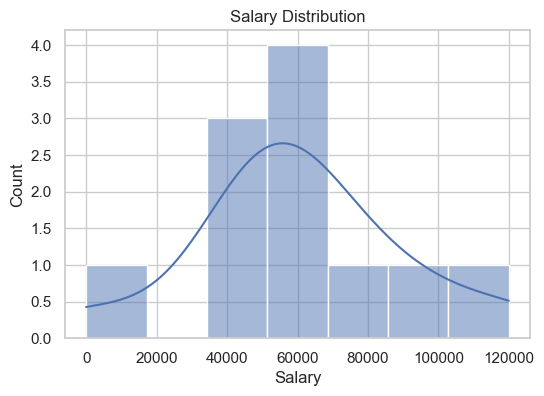

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['Salary'], kde=True)
plt.title("Salary Distribution")
plt.show()


# (B) Boxplot (Outlier Detection)

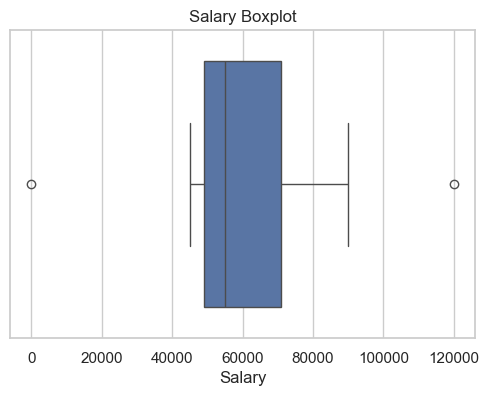

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x = df['Salary'])
plt.title("Salary Boxplot")
plt.show()


# (C) Categorical Count

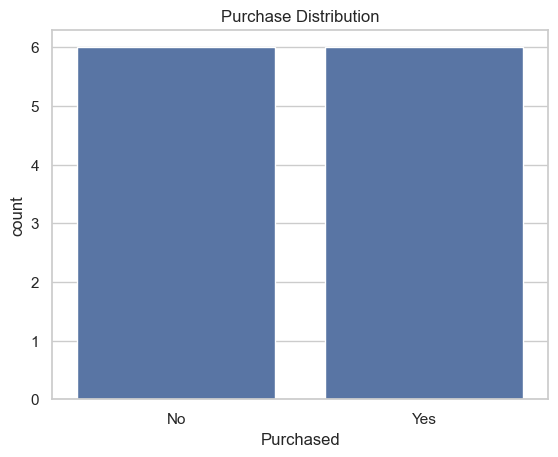

In [17]:
sns.countplot(x=df['Purchased'])
plt.title("Purchase Distribution")
plt.show()


# BIVARIATE ANALYSIS

# (A) Numerical vs Numerical

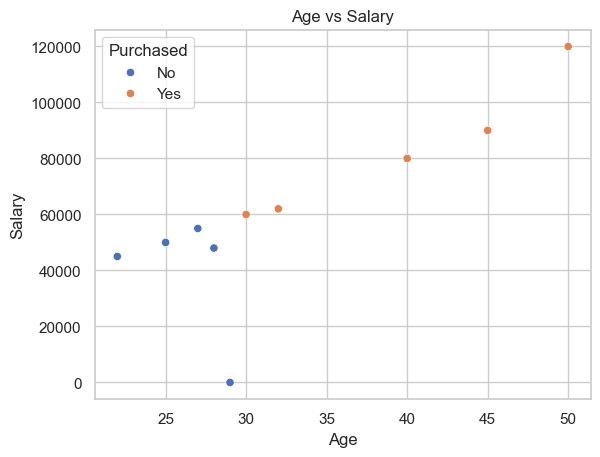

In [23]:
sns.scatterplot(x='Age', y='Salary', hue='Purchased', data=df)
plt.title("Age vs Salary")
plt.show()


# (B) Categorical vs Numerical

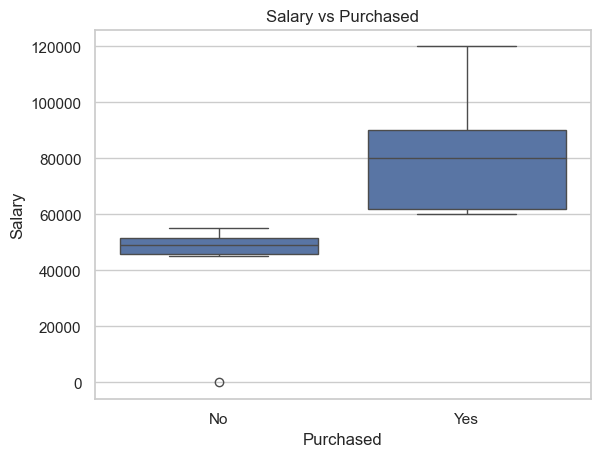

In [53]:
sns.boxplot(x='Purchased', y='Salary', data=df)
plt.title("Salary vs Purchased")
plt.show()


# Categorical vs Categorical

In [54]:
pd.crosstab(df['City'], df['Purchased'])


Purchased,No,Yes
City,,
Chennai,1,2
Delhi,3,0
Hyderabad,2,1
Mumbai,0,2


# MULTIVARIATE ANALYSIS

# Pairplot

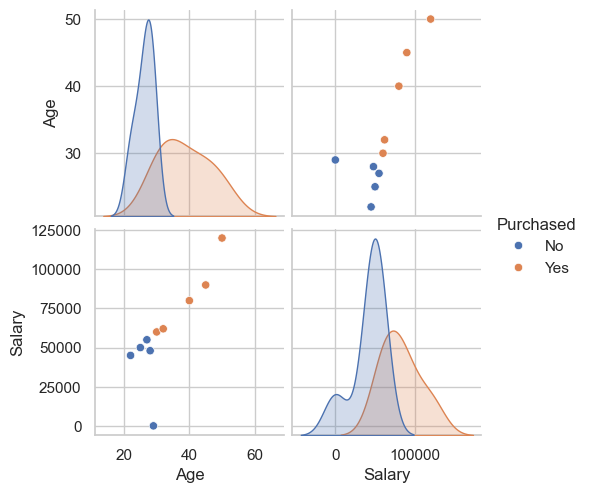

In [55]:
sns.pairplot(df[['Age','Salary','Purchased']], 
             hue='Purchased')
plt.show()


# CORRELATION HEATMAP

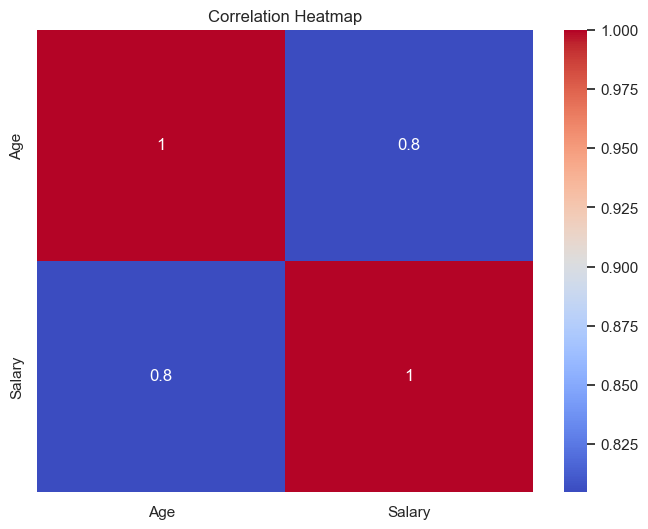

In [56]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# DETECT MULTICOLLINEARITY (VIF)

In [57]:
import numpy as np
import pandas as pd

data = {
    "Age": [25, 30, 22, 35, 40, 28, 32, 45, 29, 50, 27],
    "Salary": [50000, 60000, 45000, 70000, 80000, 52000, 62000, 90000, 48000, 120000, 55000],
    "City": ["hyderabad", "chennai", "delhi", "mumbai", "hyderabad",
             "delhi", "chennai", "mumbai", "delhi", "hyderabad", "chennai"],
    "Experience_Level": ["junior", "mid", "junior", "senior", "senior",
                         "mid", "junior", "senior", "mid", "senior", "mid"],
    "Purchased": ["no", "yes", "no", "yes", "yes",
                  "no", "yes", "yes", "no", "yes", "no"]
}

df = pd.DataFrame(data)
experience_map = {'junior':1, 'mid':2, 'senior':3}
df['Experience_Score'] = df['Experience_Level'].map(experience_map)

print(df[['Experience_Level','Experience_Score']].head())
df['Age_Salary_Interaction'] = df['Age'] * df['Salary']

print(df[['Age','Salary','Age_Salary_Interaction']].head())


  Experience_Level  Experience_Score
0           junior                 1
1              mid                 2
2           junior                 1
3           senior                 3
4           senior                 3
   Age  Salary  Age_Salary_Interaction
0   25   50000                 1250000
1   30   60000                 1800000
2   22   45000                  990000
3   35   70000                 2450000
4   40   80000                 3200000


In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_numeric = df[['Age','Salary','Experience_Score','Age_Salary_Interaction']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i)
                   for i in range(X_numeric.shape[1])]

print(vif_data)


                  Feature         VIF
0                     Age  315.142238
1                  Salary  432.474168
2        Experience_Score   23.585880
3  Age_Salary_Interaction   41.450735


# ADVANCED EDA

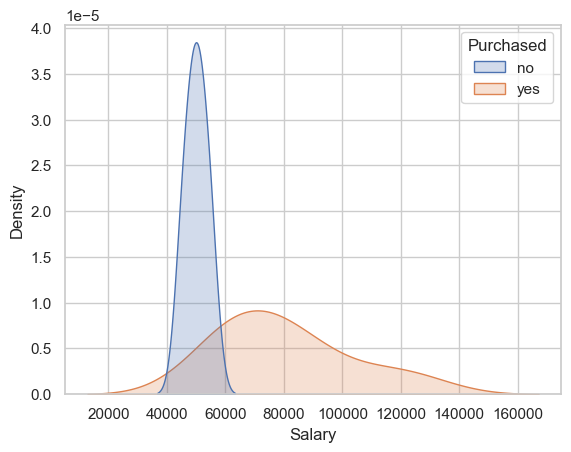

In [59]:
# Distribution Comparison by Target
sns.kdeplot(data=df, x="Salary", hue="Purchased", fill=True)
plt.show()


# Grouped Aggregation

In [60]:
df.groupby("City")["Salary"].mean()


City
chennai      59000.000000
delhi        48333.333333
hyderabad    83333.333333
mumbai       80000.000000
Name: Salary, dtype: float64

# Pivot Table

In [61]:
pd.pivot_table(df, 
               values='Salary', 
               index='City', 
               columns='Purchased',
               aggfunc='mean')


Purchased,no,yes
City,,
chennai,55000.000000,61000.0
delhi,48333.333333,NaN
hyderabad,50000.000000,100000.0
mumbai,NaN,80000.0


# TIME SERIES VISUALIZATION

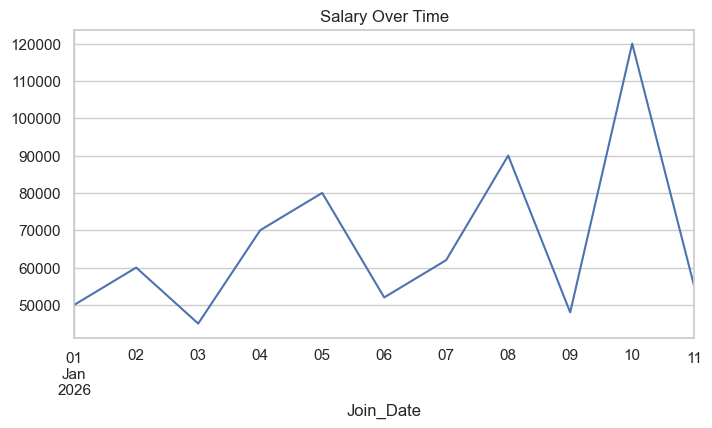

In [62]:
df['Join_Date'] = pd.date_range(start='2026-01-01', periods=len(df))

df.set_index('Join_Date', inplace=True)

df['Salary'].plot(figsize=(8,4))
plt.title("Salary Over Time")
plt.show()


# MODEL EVALUATION (Industry Level)

# TRAIN A BASE MODEL

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Simple dataset
X = df[['Age','Salary','Experience_Score']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual:", y_test.values)


Predictions: ['no' 'no' 'yes']
Actual: ['no' 'no' 'yes']


# CONFUSION MATRIX

In [64]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[2 0]
 [0 1]]


# ACCURACY

In [65]:
print("Accuracy:", accuracy_score(y_test, y_pred))
# Not good for imbalanced data.

Accuracy: 1.0


# PRECISION

In [66]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

          no       1.00      1.00      1.00         2
         yes       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



# RECALL

# F1 SCORE

# ROC CURVE & AUC

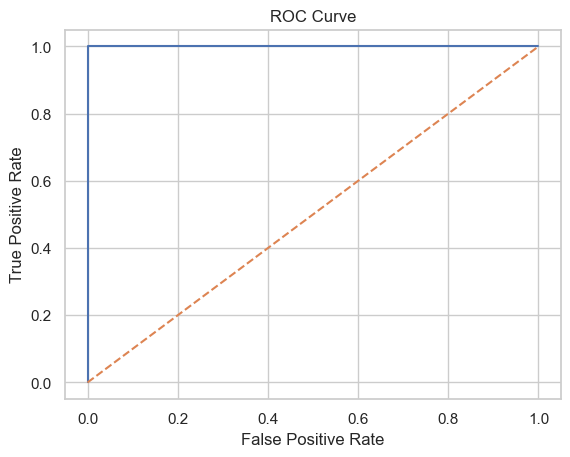

AUC Score: 1.0


In [69]:
# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test.map({'no':0,'yes':1}), y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", roc_auc_score(y_test.map({'no':0,'yes':1}), y_prob))
# AUC closer to 1 → better model.

# CROSS VALIDATION

In [70]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean CV score:", scores.mean())


Cross-validation scores: [1. 1. 1. 1. 1.]
Mean CV score: 1.0


# BIAS vs VARIANCE

# REGULARIZATION

# L1 Regularization (Lasso)

In [71]:
# Shrinks some coefficients to zero.
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')


# L2 Regularization (Ridge)

In [72]:
# Default in LogisticRegression.
model_l2 = LogisticRegression(penalty='l2')


# HYPERPARAMETER TUNING (DEEP)

# GridSearchCV

In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


C:\Users\prasa\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'C': 0.01, 'penalty': 'l2'}


# RandomizedSearchCV

In [74]:
# Faster for large parameter space.
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions={'C':[0.01,0.1,1,10]},
    n_iter=3,
    cv=5
)

random_search.fit(X_train, y_train)

print("Best Random Params:", random_search.best_params_)


C:\Users\prasa\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best Random Params: {'C': 0.01}
